In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
ticker = "MSFT"
train_df = yfinance.download(ticker, '2020-01-01', '2026-01-01')
val_df = yfinance.download(ticker, '2026-01-01', '2026-08-27')

/tmp/ipykernel_2979/613081045.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  train_df = yfinance.download(ticker, '2020-01-01', '2026-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2979/613081045.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  val_df = yfinance.download(ticker, '2026-01-01', '2026-08-27')
[*********************100%***********************]  1 of 1 completed


In [4]:
df = yfinance.download(ticker, '2020-01-01', '2026-08-27')

/tmp/ipykernel_2979/446727226.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yfinance.download(ticker, '2020-01-01', '2026-08-27')
[*********************100%***********************]  1 of 1 completed


In [5]:
val_df

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2026-01-02,469.958496,481.604612,467.196023,481.336325,25571600
2026-01-05,469.869080,473.068781,466.540192,471.071443,25250300
2026-01-06,475.493378,475.721908,466.788593,470.813049,23037700
2026-01-07,480.422150,486.612886,474.936959,476.735546,25564200
2026-01-08,475.095917,479.617251,472.860101,478.206190,18162600
...,...,...,...,...,...
2026-08-20,481.149994,484.160004,479.500000,483.299988,20020800
2026-08-21,483.239990,486.359985,478.529999,479.880005,22510800


<Axes: xlabel='Date'>

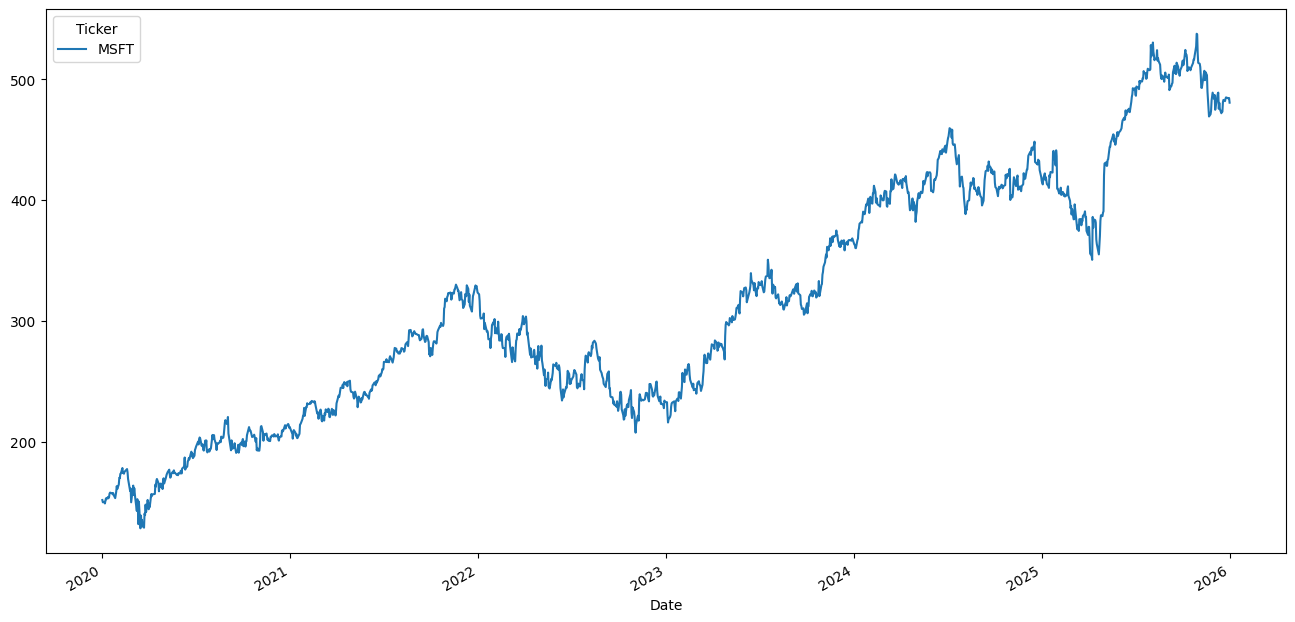

In [6]:
train_df.Close.plot(figsize=(16, 8))

In [7]:
scaler = StandardScaler()

train_df['Close'] = scaler.fit_transform(train_df['Close'])
val_df['Close'] = scaler.transform(val_df['Close'])

In [8]:
train_df.Close

Ticker,MSFT
Date,
2020-01-02,-1.617794
2020-01-03,-1.636568
2020-01-06,-1.632719
2020-01-07,-1.646330
2020-01-08,-1.622769
...,...
2025-12-24,1.699184
2025-12-26,1.696120
2025-12-29,1.690089


In [9]:
batch_size = 30

train_data = []
val_data = []

for i in range(len(train_df) - batch_size):
    train_data.append(train_df.Close[i: i+batch_size])

for i in range(len(val_df) - batch_size):
    val_data.append(val_df.Close[i: i+batch_size])
    
train_data = np.array(train_data)
val_data = np.array(val_data)

In [10]:
train_data.shape

(1478, 30, 1)

In [11]:
X_train = torch.from_numpy(train_data[:, : -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(val_data[:, : -1, :]).type(torch.Tensor).to(device)

y_train = torch.from_numpy(train_data[:, -1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(val_data[:, -1, :]).type(torch.Tensor).to(device)

In [12]:
X_train.shape

torch.Size([1478, 29, 1])

### Define our Model

In [13]:
class PredictorModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictorModel, self).__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.output_dim = output_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, X):
        h0 = torch.zeros(self.num_layers, X.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, X.size(0), self.hidden_dim, device=device)

        outputs, (hn, cn) = self.lstm(X, (h0.detach(), c0.detach()))
        outputs = self.fc(outputs[:, -1, :])

        return outputs

In [14]:
model = PredictorModel(input_dim=1, hidden_dim=32, num_layers=4, output_dim=1).to(device)

In [15]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [16]:
epochs = 300

training_loss = []
validation_loss = []

for epoch in range(epochs):

    model.train()
    y_train_pred = model(X_train)
    train_loss = criterion(y_train_pred, y_train)
    
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    training_loss.append(train_loss.item())

    model.eval()

    with torch.no_grad():
        y_test_pred = model(X_test)
        val_loss = criterion(y_test_pred, y_test)

    validation_loss.append(val_loss.item())

    print(f"for epoch = {epoch+1}/{epochs}, training_loss = {train_loss} and validation_loss = {val_loss}")


for epoch = 1/300, training_loss = 0.9814099073410034 and validation_loss = 0.8570493459701538
for epoch = 2/300, training_loss = 0.9607574343681335 and validation_loss = 0.8186694383621216
for epoch = 3/300, training_loss = 0.9131308197975159 and validation_loss = 0.7149496078491211
for epoch = 4/300, training_loss = 0.7309314012527466 and validation_loss = 0.19291198253631592
for epoch = 5/300, training_loss = 0.29627785086631775 and validation_loss = 0.37966299057006836
for epoch = 6/300, training_loss = 0.1956547498703003 and validation_loss = 0.3990747630596161
for epoch = 7/300, training_loss = 0.35259124636650085 and validation_loss = 0.31815627217292786
for epoch = 8/300, training_loss = 0.33049413561820984 and validation_loss = 0.23872296512126923
for epoch = 9/300, training_loss = 0.2710498571395874 and validation_loss = 0.18447157740592957
for epoch = 10/300, training_loss = 0.23999522626399994 and validation_loss = 0.1564674973487854
for epoch = 11/300, training_loss = 0.23

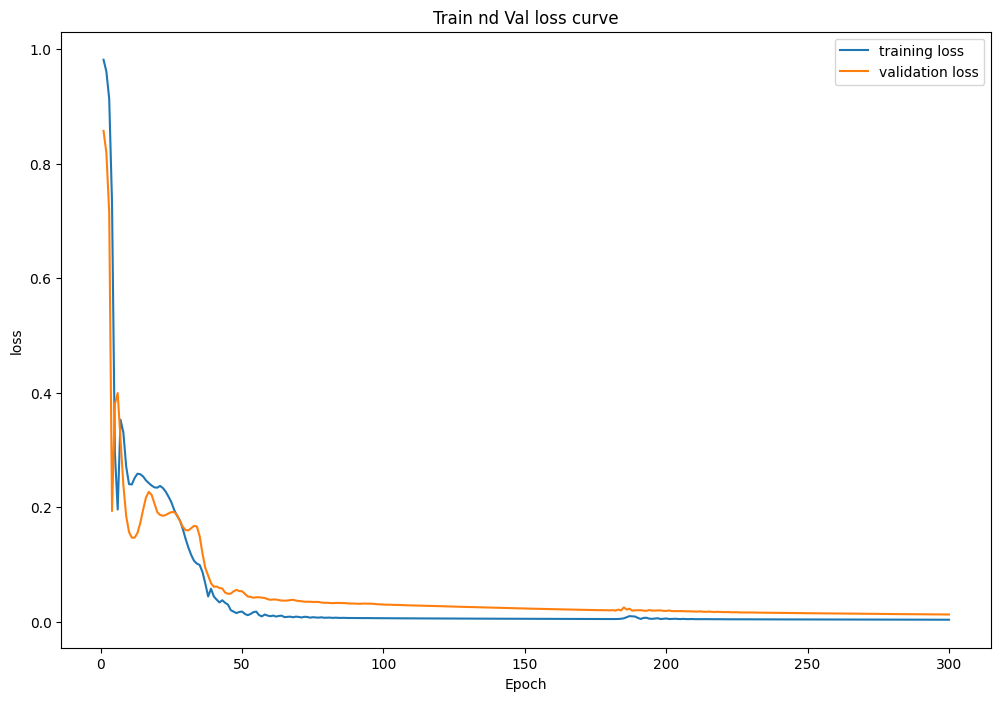

In [17]:
plt.figure(figsize=(12, 8))
plt.plot(range(1, epochs + 1), training_loss, label="training loss")
plt.plot(range(1, epochs + 1), validation_loss, label="validation loss")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("Train nd Val loss curve")
plt.show()

In [18]:
y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

In [19]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

In [20]:
print(f"train rmse: {train_rmse} and test rmse {test_rmse}")

train rmse: 5.604073524475098 and test rmse 11.11147689819336


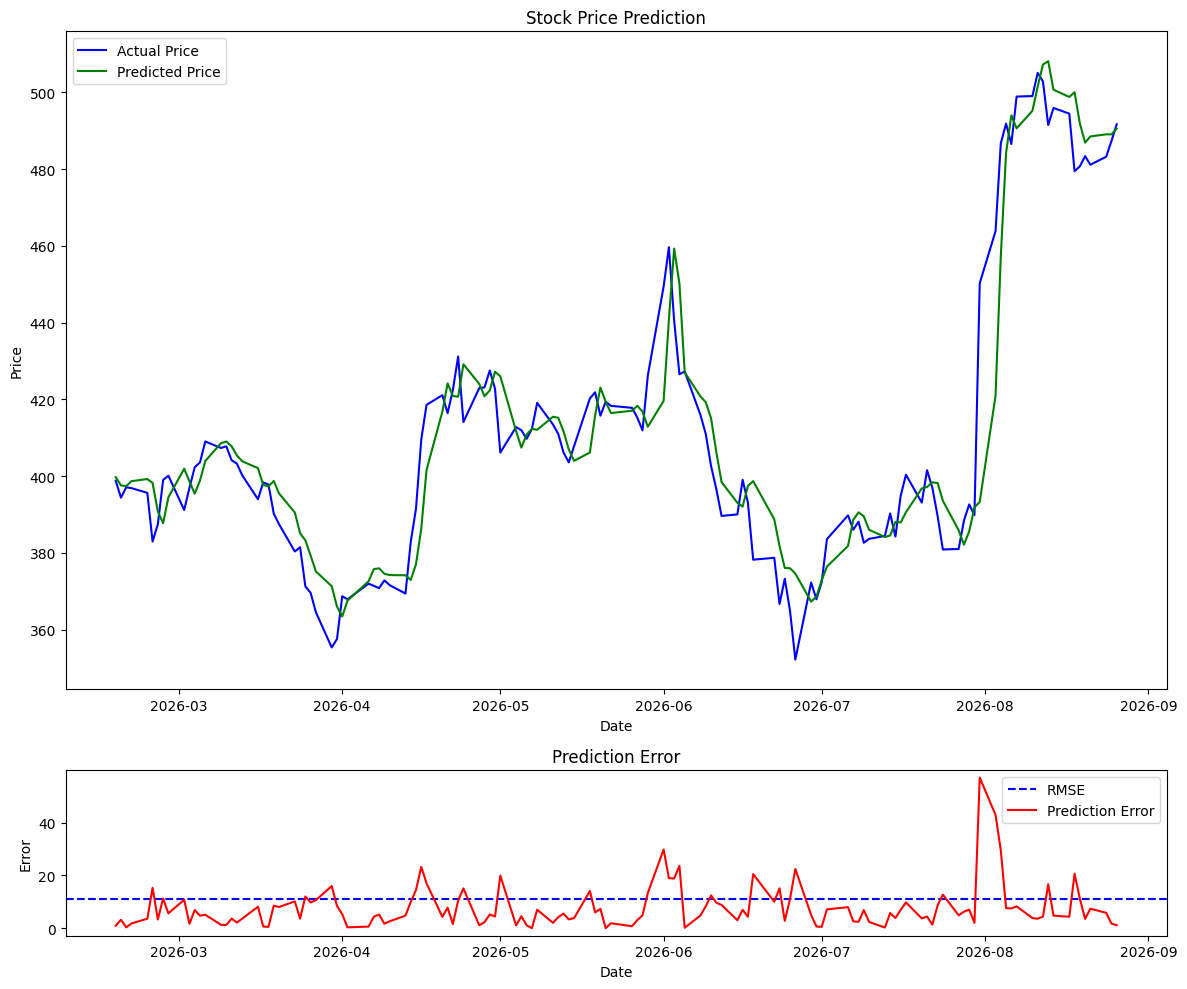

In [21]:
fig = plt.figure(figsize=(12, 10))

gs = fig.add_gridspec(4, 1)

ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color='blue', label='Actual Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color='green', label='Predicted Price')

ax1.legend()
plt.title('Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')


ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color='blue', linestyle='--', label='RMSE')
ax2.plot(df.iloc[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label='Prediction Error')

ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')

plt.tight_layout()
plt.show()